Phần 1

In [39]:

# dataset
import numpy as np
import matplotlib.pyplot as plt
import random

def get_column(data, index):
    result = []
    for row in data:          
        result.append(row[index])
    return result

def prepare_data (file_name_dataset) :
    data = np.genfromtxt(file_name_dataset, delimiter= ',', skip_header = 1).tolist()
    N = len(data)
    # get tv ( index =0)
    tv_data = get_column( data , 0)
    # get radio (index =1)
    radio_data = get_column( data , 1)
    # get newspaper (index =2)
    newspaper_data = get_column(data , 2)
    sales_data = get_column(data , 3)

    X= [tv_data, radio_data,newspaper_data]
    y= sales_data

    return X,y

In [40]:
X,y = prepare_data ( '/kaggle/input/advert/advertising.csv')


In [41]:
def initialize_params () :
    w1 , w2 , w3 , b = (0.016992259082509283 , 0.0070783670518262355 , -0.002307860847821344 , 0)
    return w1 , w2 , w3 , b

In [42]:
def predict(x1, x2, x3, w1, w2, w3, b):
    return x1*w1+x2*w2+x3*w3+b


In [43]:
def compute_loss ( y_hat , y ) :
    loss = (y_hat-y)**2
    return loss

In [44]:
def compute_gradient_wi (xi , y , y_hat ) :
    return 2*xi*(y_hat-y)

def compute_gradient_b (y , y_hat ) :
    return 2*(y_hat-y)


In [45]:
def update_weight_wi ( wi , dl_dwi , lr ) :
    w_i=wi-lr*dl_dwi
    return w_i 
def update_weight_b (b , dl_db , lr ) :
    b_new=b-lr*dl_db
    return b_new

In [46]:
def implement_linear_regression(X_data, y_data, epoch_max=50, lr=1e-5):
    losses = []

    # Khởi tạo tham số ban đầu
    w1, w2, w3, b = initialize_params()

    N = len(y_data)
    for epoch in range(epoch_max):
        total_loss = 0
        for i in range(N):
            # Lấy mẫu thứ i
            x1 = X_data[0][i]
            x2 = X_data[1][i]
            x3 = X_data[2][i]
            y = y_data[i]

            # Dự đoán
            y_hat = predict(x1, x2, x3, w1, w2, w3, b)

            # Tính loss
            loss = compute_loss(y, y_hat)
            losses.append(loss)

            # Tính gradient
            dl_dw1 = compute_gradient_wi(x1, y, y_hat)
            dl_dw2 = compute_gradient_wi(x2, y, y_hat)
            dl_dw3 = compute_gradient_wi(x3, y, y_hat)
            dl_db = compute_gradient_b(y, y_hat)

            # Cập nhật tham số
            w1 = update_weight_wi(w1, dl_dw1, lr)
            w2 = update_weight_wi(w2, dl_dw2, lr)
            w3 = update_weight_wi(w3, dl_dw3, lr)
            b = update_weight_b(b, dl_db, lr)

        

    return w1, w2, w3, b, losses

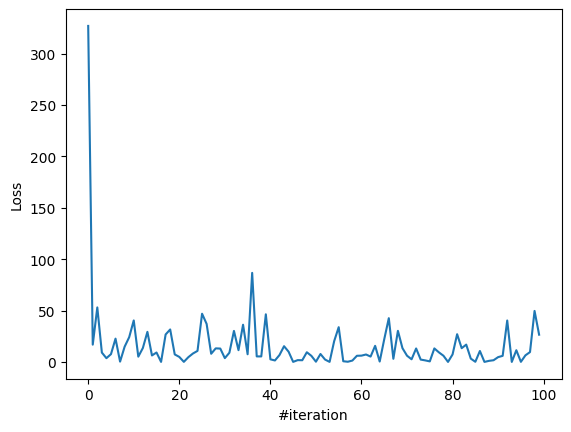

In [47]:
w1 , w2 , w3 ,b , losses  = implement_linear_regression (X , y,100 )
plt.plot (losses [:100])
plt.xlabel ("#iteration")
plt.ylabel ("Loss")
plt.show()

In [48]:
print ( w1 , w2 , w3 )


0.07349603146417186 0.15772051993288602 0.01690755305841349


In [49]:
def compute_loss_mae(y_true, y_pred):
    return abs(y_pred - y_true)

def compute_gradient_wi_mae(xi, y_true, y_pred):
    # grad = sign(y_hat - y) * xi
    if y_pred > y_true:
        sign = 1
    elif y_pred < y_true:
        sign = -1
    else:
        sign = 0
    return sign * xi

def compute_gradient_b_mae(y_true, y_pred):
    if y_pred > y_true:
        return 1
    elif y_pred < y_true:
        return -1
    else:
        return 0


In [50]:
def implement_linear_regression_with_MAE(X_data, y_data, epoch_max=50, lr=1e-5):
    losses = []

    # Khởi tạo tham số ban đầu
    w1, w2, w3, b = initialize_params()

    N = len(y_data)
    for epoch in range(epoch_max):
        total_loss = 0
        for i in range(N):
            # Lấy mẫu thứ i
            x1 = X_data[0][i]
            x2 = X_data[1][i]
            x3 = X_data[2][i]
            y = y_data[i]

            # Dự đoán
            y_hat = predict(x1, x2, x3, w1, w2, w3, b)

            # Tính loss
            loss = compute_loss_mae(y, y_hat)
            losses.append(loss)

            # Tính gradient
            dl_dw1 = compute_gradient_wi_mae(x1, y, y_hat)
            dl_dw2 = compute_gradient_wi_mae(x2, y, y_hat)
            dl_dw3 = compute_gradient_wi_mae(x3, y, y_hat)
            dl_db = compute_gradient_b_mae(y, y_hat)

            # Cập nhật tham số
            w1 = update_weight_wi(w1, dl_dw1, lr)
            w2 = update_weight_wi(w2, dl_dw2, lr)
            w3 = update_weight_wi(w3, dl_dw3, lr)
            b = update_weight_b(b, dl_db, lr)

        

    return w1, w2, w3, b, losses

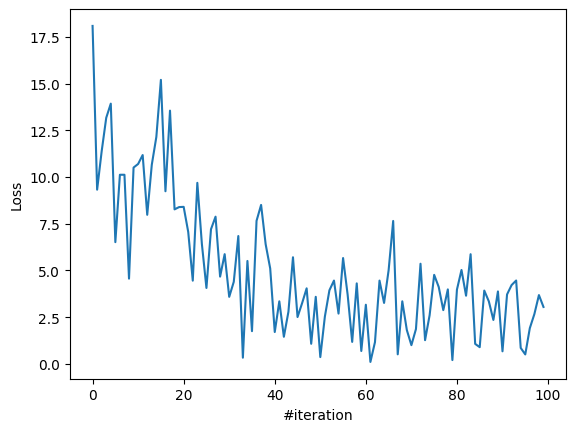

In [51]:
w1 , w2 , w3 ,b , losses  = implement_linear_regression_with_MAE (X , y,100 )
plt.plot (losses [:100])
plt.xlabel ("#iteration")
plt.ylabel ("Loss")
plt.show()

In [52]:
def implement_linear_regression_nsamples(X_data, y_data, epoch_max=50, lr=1e-5):
    losses = []
    w1, w2, w3, b = initialize_params()
    N = len(y_data)

    for epoch in range(epoch_max):
        loss_total = 0.0
        dw1_total = 0.0
        dw2_total = 0.0
        dw3_total = 0.0
        db_total = 0.0

        for i in range(N):
            # get a sample
            x1 = X_data[0][i]
            x2 = X_data[1][i]
            x3 = X_data[2][i]
            y = y_data[i]

            # compute output 
            y_hat = predict(x1, x2, x3, w1, w2, w3, b)
            
            # compute loss 
            loss = compute_loss_mae(y, y_hat)

            # accumulate total loss
            loss_total += loss

            # compute gradients
            dl_dw1 = compute_gradient_wi(x1, y, y_hat)
            dl_dw2 = compute_gradient_wi(x2, y, y_hat)
            dl_dw3 = compute_gradient_wi(x3, y, y_hat)
            dl_db  = compute_gradient_b(y, y_hat)

            # accumulate gradients
            dw1_total += dl_dw1
            dw2_total += dl_dw2
            dw3_total += dl_dw3
            db_total  += dl_db

        # (after processing N samples) - update parameters
        w1 = update_weight_wi(w1, dw1_total / N, lr)
        w2 = update_weight_wi(w2, dw2_total / N, lr)
        w3 = update_weight_wi(w3, dw3_total / N, lr)
        b  = update_weight_b(b, db_total / N, lr)

        # logging
        losses.append(loss_total / N)

    return (w1, w2, w3, b, losses)


[12.537758993110772, 5.905253690937074, 3.7290201321746137, 3.280103342013847, 3.1836865214240593, 3.1504551681146706, 3.1282032310037176, 3.107834776878128, 3.0877653671823877, 3.067869077619822, 3.0482166503078565, 3.02883345816351, 3.0097268958233707, 2.990926260388694, 2.9724018229858893, 2.954147483295836, 2.936159497829541, 2.9184793882434996, 2.9013201899015386, 2.8848065446993694, 2.8692913979087806, 2.8540808729447424, 2.8391539128581824, 2.824441258695949, 2.809939593214031, 2.795661552510065, 2.781611479829696, 2.7677616004414416, 2.7541088214511316, 2.7406510256334013, 2.727970116901554, 2.7155029638904806, 2.703211839174965, 2.6910940299623816, 2.6792629854501695, 2.6676459659520204, 2.6561923391983115, 2.645064404704684, 2.6341944320960224, 2.623535606535408, 2.6130255229490116, 2.6026618964920454, 2.592442478315787, 2.5823650549969863, 2.5725241259925906, 2.562865212228721, 2.553339917055549, 2.5439461929615637, 2.5347454167598515, 2.525816782277532, 2.517347376120849, 2

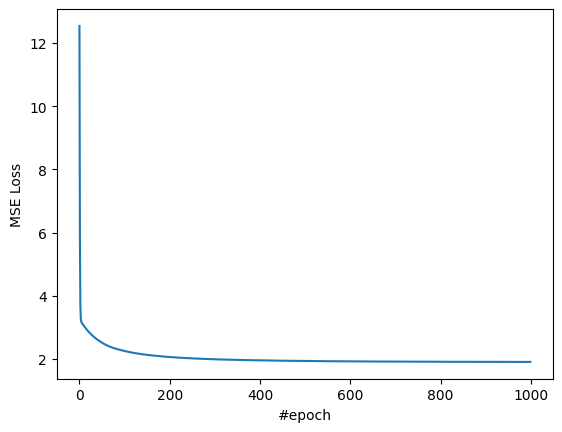

In [53]:
( w1 , w2 , w3 ,b , losses ) = implement_linear_regression_nsamples (X , y ,epoch_max =1000 ,lr =1e-5)
print(losses)
plt.plot(losses)
plt.xlabel("#epoch")
plt.ylabel ("MSE Loss")
plt.show()

In [54]:
def implement_linear_regression_nsamples(X_data, y_data, epoch_max=50, lr=1e-5):
    losses = []
    w1, w2, w3, b = initialize_params()
    N = len(y_data)

    for epoch in range(epoch_max):
        loss_total = 0.0
        dw1_total = 0.0
        dw2_total = 0.0
        dw3_total = 0.0
        db_total = 0.0

        for i in range(N):
            # get a sample
            x1 = X_data[0][i]
            x2 = X_data[1][i]
            x3 = X_data[2][i]
            y = y_data[i]

            # compute output 
            y_hat = predict(x1, x2, x3, w1, w2, w3, b)
            
            # compute loss 
            loss = compute_loss(y, y_hat)

            # accumulate total loss
            loss_total += loss

            # compute gradients
            dl_dw1 = compute_gradient_wi(x1, y, y_hat)
            dl_dw2 = compute_gradient_wi(x2, y, y_hat)
            dl_dw3 = compute_gradient_wi(x3, y, y_hat)
            dl_db  = compute_gradient_b(y, y_hat)

            # accumulate gradients
            dw1_total += dl_dw1
            dw2_total += dl_dw2
            dw3_total += dl_dw3
            db_total  += dl_db

        # (after processing N samples) - update parameters
        w1 = update_weight_wi(w1, dw1_total / N, lr)
        w2 = update_weight_wi(w2, dw2_total / N, lr)
        w3 = update_weight_wi(w3, dw3_total / N, lr)
        b  = update_weight_b(b, db_total / N, lr)

        # logging
        losses.append(loss_total / N)

    return (w1, w2, w3, b, losses)


[172.98395547828923, 39.4081674745134, 18.15746728564735, 14.634633779162357, 13.913880074022757, 13.640049637323427, 13.441395294810789, 13.259118517018994, 13.083802587178743, 12.913826664416215, 12.748804182322559, 12.58854742072041, 12.432904005847659, 12.281730988201284, 12.134890631437667, 11.992249630675893, 11.853678875589457, 11.719053303032835, 11.588251767260099, 11.461156916275085, 11.33765507239911, 11.217636116651946, 11.100993376782947, 10.987623518830576, 10.877426442098113, 10.77030517743778, 10.666165788738786, 10.564917277518694, 10.466471490519933, 10.370743030217112, 10.277649168143098, 10.187109760945372, 10.099047169086274, 10.013386178104167, 9.930053922354572, 9.848979811153313, 9.770095457245782, 9.69333460752933, 9.61863307595747, 9.545928678557278, 9.475161170493593, 9.406272185115144, 9.339205174920474, 9.273905354383018, 9.210319644576826, 9.148396619546123, 9.088086454363877, 9.029340874825948, 8.972113108729593, 8.916357838686066, 8.86203115641928, 8.809

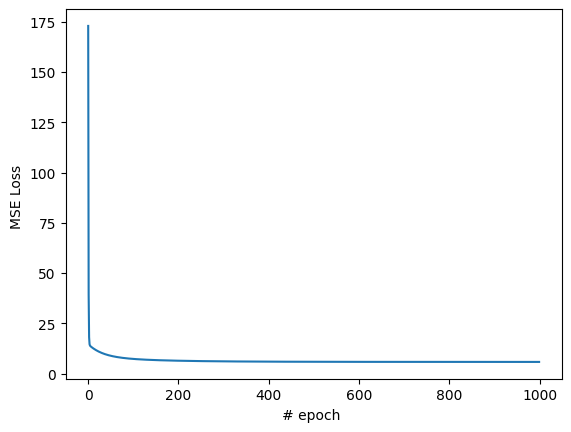

In [55]:
( w1 , w2 , w3 ,b , losses ) = implement_linear_regression_nsamples (X , y ,epoch_max =1000 ,lr =1e-5)
print ( losses )
plt . plot ( losses )
plt . xlabel ("# epoch ")
plt . ylabel ("MSE Loss ")
plt . show ()

In [56]:
def prepare_data_2(file_name_dataset) :
    data = np.genfromtxt(file_name_dataset, delimiter= ',', skip_header = 1).tolist()
    N = len(data)
    # get tv ( index =0)
    tv_data = get_column( data , 0)
    # get radio (index =1)
    radio_data = get_column( data , 1)
    # get newspaper (index =2)
    newspaper_data = get_column(data , 2)
    sales_data = get_column(data , 3)

    X = [[1,x1,x2,x3] for x1 , x2 , x3 in zip( tv_data , radio_data , newspaper_data ) ]
    y= sales_data

    return X,y

In [57]:
def initialize_params():
    bias = 0
    w1 = random . gauss ( mu =0.0 , sigma =0.01)
    w2 = random . gauss ( mu =0.0 , sigma =0.01)
    w3 = random . gauss ( mu =0.0 , sigma =0.01)
    return [bias , w1 , w2 , w3]

In [58]:
def predict(X_features, weights):
    return sum([f*w for f,w in zip(X_features,weights)])

In [59]:
def compute_loss(y_hat, y):
    return (y_hat - y)**2


def compute_gradient_w(X_features, y, y_hat):
    return [2*X*(y_hat-y) for X in X_features]

def update_weight(weights, dl_dweights, lr):
    return [w-lr*dw for w,dw in zip(weights,dl_dweights)]

In [60]:
def implement_linear_regression_2(X_feature, y_ouput, epoch_max = 100,lr = 1e-5):

  losses = []
  weights = initialize_params()
  N = len(y_ouput)
  for epoch in range(epoch_max):
      for i in range(N):
          # get a sample - row i     
          features_i = X_feature[i]
          y = y_ouput[i]
          
          # compute output 
          y_hat = predict(features_i, weights)

          # compute loss
          loss = compute_loss(y, y_hat)

          # compute gradient w1, w2, w3, b
          dl_dweights = compute_gradient_w(features_i, y, y_hat)

          # update parameters
          weights = update_weight(weights, dl_dweights, lr)

          # logging
          losses.append(loss) 
  return weights, losses

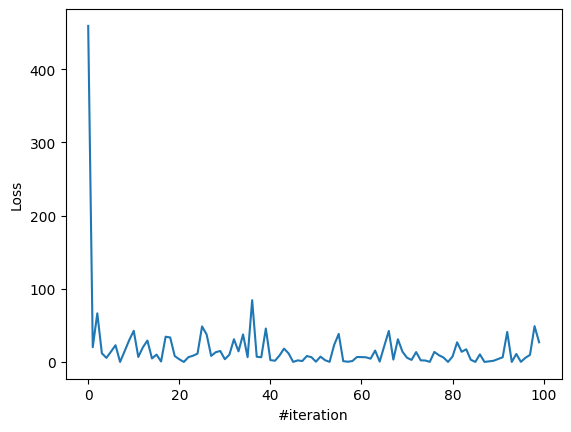

In [61]:
X,y = prepare_data_2('/kaggle/input/advert/advertising.csv')
W,L = implement_linear_regression_2(X,y)
plt.plot(L[0:100])
plt.xlabel("#iteration")
plt.ylabel("Loss")
plt.show()